In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [17]:

df = pd.read_csv("../data/hour.csv")
features = [
    "hr",
    "weekday",
    "workingday",
    "temp",
    "hum",
    "windspeed",
    "cnt"
]

X = df[features]
X.head()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

scores = {}

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"k = {k}, silhouette score = {score:.4f}")
    
results_df = pd.DataFrame(
    list(scores.items()),
    columns=["k", "silhouette_score"]
)

results_df.to_csv("static/kmeans_silhouette_results.csv", index=False)

k = 2, silhouette score = 0.1814
k = 3, silhouette score = 0.1692
k = 4, silhouette score = 0.1687
k = 5, silhouette score = 0.1722
k = 6, silhouette score = 0.1868
k = 7, silhouette score = 0.1856


In [37]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Save to CSV
df[["hr", "cnt", "cluster"]].to_csv(
    "static/kmeans_cluster_result.csv",
    index=False
)

# Optional: preview
df[["hr", "cnt", "cluster"]].head()

,hr,cnt,cluster
0,0,16,1
1,1,40,1
2,2,32,1
3,3,13,1
4,4,1,1


In [24]:
cluster_summary = df.groupby("cluster")[features].mean()
cluster_summary.to_csv("static/cluster_summary.csv")

In [12]:
df["cluster"].value_counts()

cluster
2    6352
0    6076
1    4951
Name: count, dtype: int64

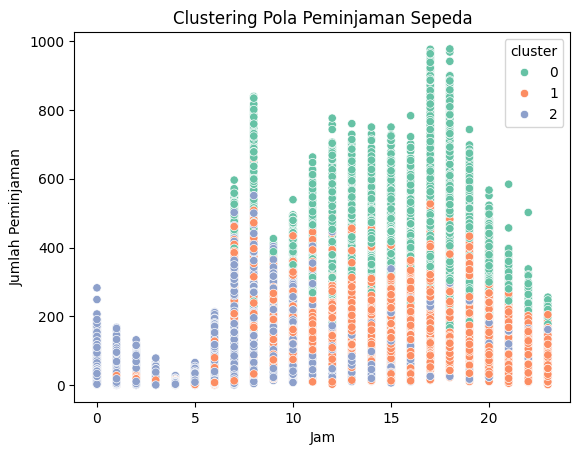

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=df,
    x="hr",
    y="cnt",
    hue="cluster",
    palette="Set2"
)
plt.title("Clustering Pola Peminjaman Sepeda")
plt.xlabel("Jam")
plt.ylabel("Jumlah Peminjaman")

# 🔹 SAVE IMAGE
plt.savefig(
    "static/cluster_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
dbscan_counts = (
    df["cluster_dbscan"]
    .value_counts()
    .reset_index()
)

dbscan_counts.columns = ["cluster_dbscan", "n_samples"]

dbscan_counts.to_csv(
    "static/dbscan_cluster_counts.csv",
    index=False
)

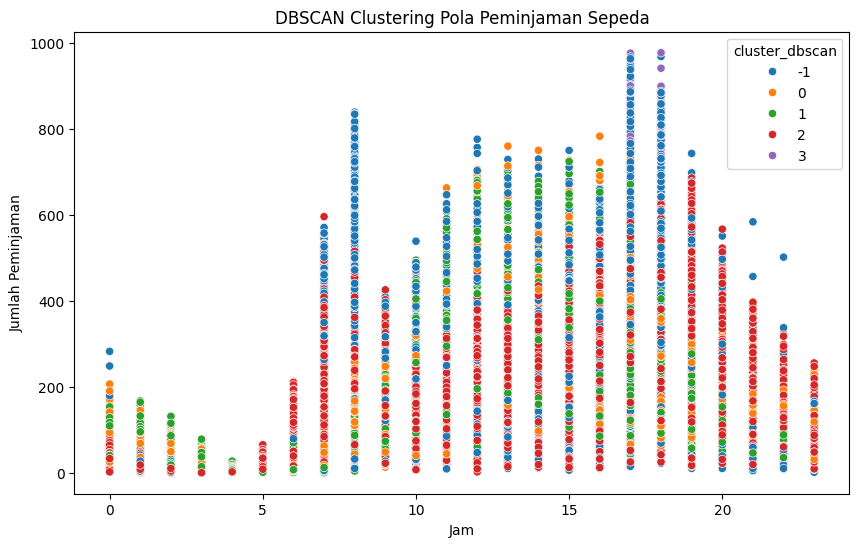

In [29]:
plt.figure(figsize=(10, 6))  # recommended for web

sns.scatterplot(
    data=df,
    x="hr",
    y="cnt",
    hue="cluster_dbscan",
    palette="tab10"
)

plt.title("DBSCAN Clustering Pola Peminjaman Sepeda")
plt.xlabel("Jam")
plt.ylabel("Jumlah Peminjaman")

# 🔹 SAVE IMAGE
plt.savefig(
    "static/dbscan_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

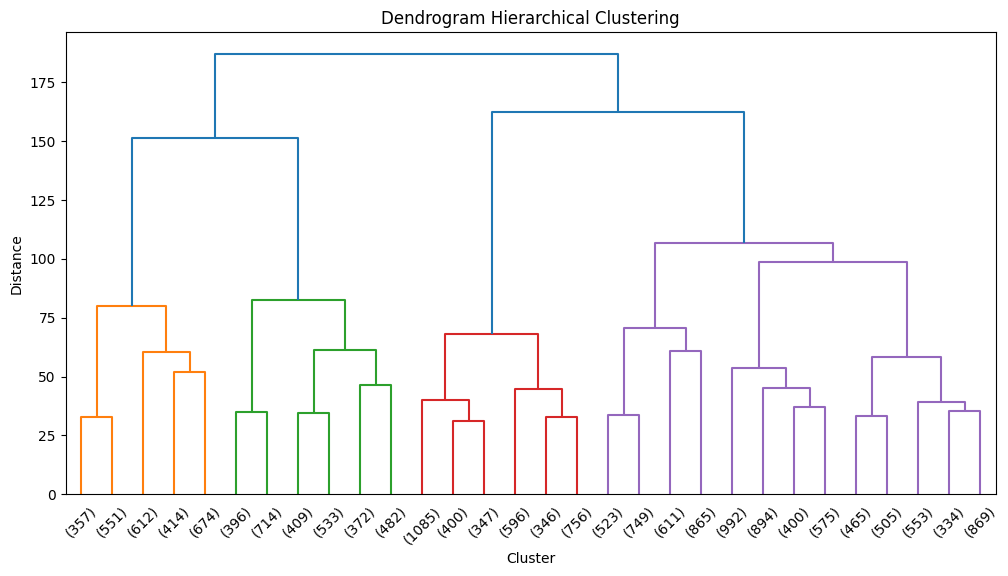

In [30]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Dendrogram Hierarchical Clustering")
plt.xlabel("Cluster")
plt.ylabel("Distance")

# 🔹 SAVE IMAGE
plt.savefig(
    "static/hierarchical_dendrogram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
